In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visualization style for all plots
sns.set_theme(style="whitegrid", palette="muted")

# Define the directory where your 17 CSV files are stored
DATA_DIR = '../data/PRO-ACT_Data/2026_02_27_PROACT_ALL_FORMS/' 

# ---------------------------------------------------------
# 1. DATA LOADING
# ---------------------------------------------------------
def load_data(filename):
    """Safely load a CSV file into a pandas DataFrame."""
    file_path = os.path.join(DATA_DIR, filename)
    try:
        print(f"Loading {filename}...")
        return pd.read_csv(file_path, low_memory=False)
    except FileNotFoundError:
        print(f"  -> Warning: {filename} not found. Skipping.")
        return None


In [5]:
print("=== PART 1: LOADING DATASETS ===")
datasets = {
    'demographics': load_data('F_PROACT_DEMOGRAPHICS.csv'),
    'alsfrs': load_data('F_PROACT_ALSFRS.csv'),
    'death': load_data('F_PROACT_DEATHDATA.csv'),
    'treatment': load_data('F_PROACT_TREATMENT.csv'),
    'riluzole': load_data('F_PROACT_RILUZOLE.csv'),
    'fvc': load_data('F_PROACT_FVC.csv'),
    'svc': load_data('F_PROACT_SVC.csv'),
    'vitals': load_data('F_PROACT_VITALSIGNS.csv'),
    'handgrip': load_data('F_PROACT_HANDGRIPSTRENGTH.csv'),
    'muscle': load_data('F_PROACT_MUSCLESTRENGTH.csv'),
    'neurofilament': load_data('F_PROACT_Neurofilament.csv'),
    'adverse_events': load_data('F_PROACT_ADVERSEEVENTS.csv'),
    'history': load_data('F_PROACT_ALSHISTORY.csv'),
    'conmeds': load_data('F_PROACT_CONMEDS.csv'),
    'elescorial': load_data('F_PROACT_ELESCORIAL.csv'),
    'family': load_data('F_PROACT_FAMILYHISTORY.csv'),
    'labs': load_data('F_PROACT_LABS.csv')
}

=== PART 1: LOADING DATASETS ===
Loading F_PROACT_DEMOGRAPHICS.csv...
Loading F_PROACT_ALSFRS.csv...
Loading F_PROACT_DEATHDATA.csv...
Loading F_PROACT_TREATMENT.csv...
Loading F_PROACT_RILUZOLE.csv...
Loading F_PROACT_FVC.csv...
Loading F_PROACT_SVC.csv...
Loading F_PROACT_VITALSIGNS.csv...
Loading F_PROACT_HANDGRIPSTRENGTH.csv...
Loading F_PROACT_MUSCLESTRENGTH.csv...
Loading F_PROACT_Neurofilament.csv...
Loading F_PROACT_ADVERSEEVENTS.csv...
Loading F_PROACT_ALSHISTORY.csv...
Loading F_PROACT_CONMEDS.csv...
Loading F_PROACT_ELESCORIAL.csv...
Loading F_PROACT_FAMILYHISTORY.csv...
Loading F_PROACT_LABS.csv...


In [4]:

# Define the 12 ALSFRS-R items as a constant so it can be used during loading
ITEM_COLS = [
    'Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing', 'Q4_Handwriting',
    'Q5_Cutting', 'Q6_Dressing_and_Hygiene', 'Q7_Turning_in_Bed',
    'Q8_Walking', 'Q9_Climbing_Stairs', 'R_1_Dyspnea',
    'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency'
]

def get_covariate_lists(scenario):
    """
    Returns the measurement and dynamic covariates based on the selected scenario.
    """
    if scenario == 'S1':
        meas_cols = ['Treatment_Active', 'Sex_Female', 'Age_Base']
        dyn_cols = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
    elif scenario == 'S2':
        meas_cols = ['Treatment_Active', 'Sex_Female', 'Age_Base']
        dyn_cols = ['Bulbar_Onset']
    elif scenario == 'S3':
        meas_cols = ['Treatment_Active', 'Sex_Female']
        dyn_cols = ['Age_Base', 'Bulbar_Onset']
    else:
        raise ValueError(f"Invalid scenario specified: {scenario}")
        
    return meas_cols, dyn_cols

def preprocess_proact_data(dfs, scenario="S1", output_filename="proact_preprocessed.csv"):
    """
    Preprocesses the PRO-ACT dataset dictionary.
    Filters complete cases dynamically based on the covariates required for the chosen scenario.
    """
    meas_cols, dyn_cols = get_covariate_lists(scenario)
    active_covariates = list(set(meas_cols + dyn_cols))
    
    # 1. RESPONSE VARIABLES (Y) & TIME
    df_alsfrs = dfs['alsfrs'].copy()
    df_alsfrs['Q5_Cutting'] = df_alsfrs['Q5b_Cutting_with_Gastrostomy'].fillna(df_alsfrs['Q5a_Cutting_without_Gastrostomy'])
    df_model = df_alsfrs[['subject_id', 'ALSFRS_Delta'] + ITEM_COLS].copy()
    df_model = df_model.dropna(subset=['ALSFRS_Delta'])
    
    # 2. MEASUREMENT COVARIATES (Process all to be safe)
    df_demo = dfs['demographics'].copy()
    df_demo['Sex_Female'] = (df_demo['Sex'] == 'Female').astype(float)
    df_demo_clean = df_demo.groupby('subject_id')[['Age', 'Sex_Female']].first().reset_index()
    df_demo_clean.rename(columns={'Age': 'Age_Base'}, inplace=True)
    
    df_tx = dfs['treatment'].copy()
    df_tx['Treatment_Active'] = df_tx['Study_Arm'].str.contains('Active', case=False, na=False).astype(float)
    df_tx_clean = df_tx.groupby('subject_id')[['Treatment_Active']].first().reset_index()
    
    # 3. DYNAMIC COVARIATES (Process all to be safe)
    df_hist = dfs['history'].copy()
    if 'Site_of_Onset___Bulbar' in df_hist.columns:
        df_hist['Bulbar_Onset'] = df_hist['Site_of_Onset___Bulbar'].fillna(0)
    else:
        df_hist['Bulbar_Onset'] = (df_hist['Site_of_Onset'] == 'Bulbar').astype(float)
    df_hist_clean = df_hist.groupby('subject_id')[['Bulbar_Onset']].first().reset_index()
    
    df_fvc = dfs['fvc'].copy()
    df_fvc['pct_of_Normal_Trial_1'] = pd.to_numeric(df_fvc['pct_of_Normal_Trial_1'], errors='coerce')
    fvc = df_fvc.dropna(subset=['pct_of_Normal_Trial_1', 'Forced_Vital_Capacity_Delta']).copy()
    fvc['abs_delta'] = fvc['Forced_Vital_Capacity_Delta'].abs()
    fvc_base = fvc.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    fvc_base = fvc_base.rename(columns={'pct_of_Normal_Trial_1': 'FVC_Base'})[['subject_id', 'FVC_Base']]
    
    df_vitals = dfs['vitals'].copy()
    df_vitals['Height_m'] = np.where(
        df_vitals['Height_Units'].str.lower().str.contains('in', na=False), 
        df_vitals['Height'] * 0.0254, df_vitals['Height'] / 100.0
    )
    heights = df_vitals.dropna(subset=['Height_m']).groupby('subject_id')['Height_m'].median().reset_index()
    
    df_vitals['Weight_kg'] = np.where(
        df_vitals['Weight_Units'].str.lower().str.contains('lb|pound', na=False), 
        df_vitals['Weight'] * 0.453592, df_vitals['Weight']
    )
    weights = df_vitals.dropna(subset=['Weight_kg', 'Vital_Signs_Delta']).copy()
    weights['abs_delta'] = weights['Vital_Signs_Delta'].abs()
    weights_base = weights.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    
    bmi_df = weights_base[['subject_id', 'Weight_kg']].merge(heights, on='subject_id', how='left')
    bmi_df['BMI_Base'] = bmi_df['Weight_kg'] / (bmi_df['Height_m'] ** 2)
    bmi_base = bmi_df[['subject_id', 'BMI_Base']]
    
    # 4. MERGE
    df_model = df_model.merge(df_demo_clean, on='subject_id', how='left')
    df_model = df_model.merge(df_tx_clean, on='subject_id', how='left')
    df_model = df_model.merge(df_hist_clean, on='subject_id', how='left')
    df_model = df_model.merge(fvc_base, on='subject_id', how='left')
    df_model = df_model.merge(bmi_base, on='subject_id', how='left')
    
    # Sort chronologically
    df_model = df_model.sort_values(by=['subject_id', 'ALSFRS_Delta']).reset_index(drop=True)
    
    # 5. DYNAMIC COMPLETE CASE FILTER
    # Only drop rows missing the specific covariates required by the chosen scenario
    required_cols = ITEM_COLS + active_covariates
    df_complete = df_model.dropna(subset=required_cols).reset_index(drop=True)
    
    # Standardize continuous covariates for Stan HMC stability
    continuous_vars = ['Age_Base', 'FVC_Base', 'BMI_Base']
    for col in continuous_vars:
        if col in df_complete.columns and col in active_covariates:
            df_complete[col] = (df_complete[col] - df_complete[col].mean()) / df_complete[col].std()
            
    # Save the prepared data to file
    df_complete.to_csv(output_filename, index=False)
    print(f"Preprocessed data for {scenario} successfully saved to '{output_filename}' (N={len(df_complete)})")
    
    return df_complete

preprocess_proact_data(datasets, scenario="S3", output_filename="proact_preprocessed_S3.csv")

Preprocessed data for S3 successfully saved to 'proact_preprocessed_S3.csv' (N=36182)


,subject_id,ALSFRS_Delta,Q1_Speech,Q2_Salivation,Q3_Swallowing,Q4_Handwriting,Q5_Cutting,Q6_Dressing_and_Hygiene,Q7_Turning_in_Bed,Q8_Walking,Q9_Climbing_Stairs,R_1_Dyspnea,R_2_Orthopnea,R_3_Respiratory_Insufficiency,Age_Base,Sex_Female,Treatment_Active,Bulbar_Onset,FVC_Base,BMI_Base
0,6787,0.0,3.0,4.0,3.0,3.0,3.0,2.0,2.0,2.0,1.0,4.0,4.0,4.0,-0.591656,0.0,0.0,0.0,121.0,NaN
1,6787,25.0,3.0,4.0,4.0,3.0,1.0,2.0,2.0,2.0,1.0,4.0,4.0,4.0,-0.591656,0.0,0.0,0.0,121.0,NaN
2,6787,59.0,3.0,3.0,3.0,2.0,1.0,2.0,2.0,2.0,1.0,4.0,4.0,4.0,-0.591656,0.0,0.0,0.0,121.0,NaN
3,6787,91.0,3.0,4.0,3.0,2.0,1.0,1.0,1.0,1.0,0.0,3.0,3.0,4.0,-0.591656,0.0,0.0,0.0,121.0,NaN
4,6787,115.0,3.0,4.0,3.0,1.0,1.0,0.0,0.0,2.0,1.0,3.0,3.0,4.0,-0.591656,0.0,0.0,0.0,121.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36177,9998247,68.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,3.0,2.0,2.0,4.0,4.0,-0.238533,0.0,1.0,0.0,99.0,2651.234568
36178,9998247,95.0,3.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,2.0,2.0,3.0,4.0,-0.238533,0.0,1.0,0.0,99.0,2651.234568
36179,9998247,123.0,3.0,3.0,3.0,2.0,1.0,2.0,3.0,3.0,2.0,2.0,3.0,3.0,-0.238533,0.0,1.0,0.0,99.0,2651.234568
36180,9998247,151.0,3.0,3.0,3.0,2.0,2.0,3.0,3.0,2.0,2.0,2.0,4.0,4.0,-0.238533,0.0,1.0,0.0,99.0,2651.234568


In [23]:
import pandas as pd
import numpy as np

def prepare_dfa_ou_data(dfs):
    """
    Preprocesses the PRO-ACT dataset for a continuous-time DFA-OU model.
    Extracts Y (ALSFRS-R), t (Delta), x^(y) (Measurement covariates), 
    and x^(xi) (Structural covariates including Uric Acid & Creatinine).
    Filters the final dataset to only include complete cases (no missing items or covariates).
    """
    
    # =========================================================================
    # 1. RESPONSE VARIABLES (Y) & TIME (t)
    # =========================================================================
    df_alsfrs = dfs['alsfrs'].copy()
    
    # Q5 DIF: Time-varying Gastrostomy Status (1 if tube present, 0 otherwise)
    df_alsfrs['Gastrostomy_Status'] = df_alsfrs['Q5b_Cutting_with_Gastrostomy'].notna().astype(float)
    df_alsfrs['Q5_Cutting'] = df_alsfrs['Q5b_Cutting_with_Gastrostomy'].fillna(df_alsfrs['Q5a_Cutting_without_Gastrostomy'])
    
    item_cols = [
        'Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing', 'Q4_Handwriting',
        'Q5_Cutting', 'Q6_Dressing_and_Hygiene', 'Q7_Turning_in_Bed',
        'Q8_Walking', 'Q9_Climbing_Stairs', 'R_1_Dyspnea',
        'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency'
    ]
    
    # Base longitudinal dataframe
    df_model = df_alsfrs[['subject_id', 'ALSFRS_Delta', 'Gastrostomy_Status'] + item_cols].copy()
    df_model = df_model.dropna(subset=['ALSFRS_Delta'])
    
    # =========================================================================
    # 2. MEASUREMENT COVARIATES: x^(y)
    # =========================================================================
    
    # --- Demographics: Age and Sex ---
    df_demo = dfs['demographics'].copy()
    df_demo['Sex_Female'] = (df_demo['Sex'] == 'Female').astype(float)
    df_demo_clean = df_demo.groupby('subject_id')[['Age', 'Sex_Female']].first().reset_index()
    df_demo_clean.rename(columns={'Age': 'Baseline_Age'}, inplace=True)
    
    # --- Treatment Group ---
    df_tx = dfs['treatment'].copy()
    # Map 'Active' to 1, 'Placebo' to 0
    df_tx['Treatment_Active'] = df_tx['Study_Arm'].str.contains('Active', case=False, na=False).astype(float)
    df_tx_clean = df_tx.groupby('subject_id')[['Treatment_Active']].first().reset_index()
    
    # =========================================================================
    # 3. STRUCTURAL / DYNAMIC COVARIATES: x^(xi)
    # =========================================================================
    
    # --- Site of Onset ---
    df_hist = dfs['history'].copy()
    if 'Site_of_Onset___Bulbar' in df_hist.columns:
        df_hist['Bulbar_Onset'] = df_hist['Site_of_Onset___Bulbar'].fillna(0)
    else:
        df_hist['Bulbar_Onset'] = (df_hist['Site_of_Onset'] == 'Bulbar').astype(float)
    df_hist_clean = df_hist.groupby('subject_id')[['Bulbar_Onset']].first().reset_index()
    
    # --- Baseline FVC ---
    df_fvc = dfs['fvc'].copy()
    df_fvc['pct_of_Normal_Trial_1'] = pd.to_numeric(df_fvc['pct_of_Normal_Trial_1'], errors='coerce')
    fvc = df_fvc.dropna(subset=['pct_of_Normal_Trial_1', 'Forced_Vital_Capacity_Delta']).copy()
    
    fvc['abs_delta'] = fvc['Forced_Vital_Capacity_Delta'].abs()
    fvc_base = fvc.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    fvc_base = fvc_base.rename(columns={'pct_of_Normal_Trial_1': 'Baseline_FVC_pct'})[['subject_id', 'Baseline_FVC_pct']]
    
    # --- Baseline BMI ---
    df_vitals = dfs['vitals'].copy()
    
    df_vitals['Height_m'] = np.where(
        df_vitals['Height_Units'].str.lower().str.contains('in', na=False), 
        df_vitals['Height'] * 0.0254, 
        df_vitals['Height'] / 100.0
    )
    heights = df_vitals.dropna(subset=['Height_m']).groupby('subject_id')['Height_m'].median().reset_index()
    
    df_vitals['Weight_kg'] = np.where(
        df_vitals['Weight_Units'].str.lower().str.contains('lb|pound', na=False), 
        df_vitals['Weight'] * 0.453592, 
        df_vitals['Weight']
    )
    
    weights = df_vitals.dropna(subset=['Weight_kg', 'Vital_Signs_Delta']).copy()
    weights['abs_delta'] = weights['Vital_Signs_Delta'].abs()
    weights_base = weights.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    
    bmi_df = weights_base[['subject_id', 'Weight_kg']].merge(heights, on='subject_id', how='left')
    bmi_df['Baseline_BMI'] = bmi_df['Weight_kg'] / (bmi_df['Height_m'] ** 2)
    bmi_base = bmi_df[['subject_id', 'Baseline_BMI']]
    
    # --- Baseline Lab Biomarkers (Uric Acid & Creatinine) ---
    df_labs = dfs['labs'].copy()
    df_labs['Test_Result'] = pd.to_numeric(df_labs['Test_Result'], errors='coerce')
    df_labs = df_labs.dropna(subset=['Test_Result', 'Laboratory_Delta'])
    df_labs['abs_delta'] = df_labs['Laboratory_Delta'].abs()

    # Uric Acid
    uric = df_labs[df_labs['Test_Name'].str.contains('Uric Acid', case=False, na=False)]
    uric_base = uric.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    uric_base = uric_base.rename(columns={'Test_Result': 'Baseline_Uric_Acid'})[['subject_id', 'Baseline_Uric_Acid']]

    # Creatinine (Exact match string to avoid BUN/Creatinine ratios)
    creat = df_labs[df_labs['Test_Name'].str.strip().str.lower() == 'creatinine']
    creat_base = creat.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    creat_base = creat_base.rename(columns={'Test_Result': 'Baseline_Creatinine'})[['subject_id', 'Baseline_Creatinine']]
    
    # =========================================================================
    # 4. FINAL MERGE & SEQUENCE SORTING
    # =========================================================================
    
    # Merge all covariates
    df_model = df_model.merge(df_demo_clean, on='subject_id', how='left')
    df_model = df_model.merge(df_tx_clean, on='subject_id', how='left')
    df_model = df_model.merge(df_hist_clean, on='subject_id', how='left')
    df_model = df_model.merge(fvc_base, on='subject_id', how='left')
    df_model = df_model.merge(bmi_base, on='subject_id', how='left')
    df_model = df_model.merge(uric_base, on='subject_id', how='left')
    df_model = df_model.merge(creat_base, on='subject_id', how='left')
    
    df_model = df_model.sort_values(by=['subject_id', 'ALSFRS_Delta']).reset_index(drop=True)
    
    # Ensure float32 casting for PyTorch
    # covariate_cols = [
    #     'Gastrostomy_Status', 'Baseline_Age', 'Sex_Female', 'Treatment_Active', 
    #     'Bulbar_Onset', 'Baseline_FVC_pct', 'Baseline_BMI',
    #     'Baseline_Uric_Acid', 'Baseline_Creatinine'
    # ]
    covariate_cols = [
        'Gastrostomy_Status', 'Baseline_Age', 'Sex_Female', 'Treatment_Active', 
        'Bulbar_Onset', 'Baseline_FVC_pct', 'Baseline_BMI'
    ]
    df_model[covariate_cols] = df_model[covariate_cols].astype(np.float32)

    # =========================================================================
    # 5. FILTER COMPLETE CASES
    # =========================================================================
    
    # List of all required columns (Items + Covariates)
    required_cols = item_cols + covariate_cols
    
    # Drop rows where ANY of the required columns are NaN
    df_complete = df_model.dropna(subset=required_cols).reset_index(drop=True)
    
    return df_complete

final_df = prepare_dfa_ou_data(datasets)

In [24]:
print(final_df["subject_id"].nunique(), len(final_df))


775 4336


In [ ]:
import pandas as pd
import numpy as np

def preprocess_proact_for_irt(dfs):
    """
    Preprocesses the PRO-ACT dataset dictionary for a Continuous-Time IRT/DFA-OU model.
    """
    
    # -------------------------------------------------------------------------
    # 1. PROCESS LONGITUDINAL MEASUREMENTS (Y) & DYNAMIC COVARIATES (x^y)
    # -------------------------------------------------------------------------
    df_alsfrs = dfs['alsfrs'].copy()
    
    # Derive time-varying Gastrostomy Status (x^y for Item 5 DIF)
    # If Q5b is not null, they have a gastrostomy.
    df_alsfrs['Gastrostomy_Status'] = df_alsfrs['Q5b_Cutting_with_Gastrostomy'].notna().astype(int)
    
    # Combine Q5a and Q5b into a single unified Q5 column
    df_alsfrs['Q5_Cutting'] = df_alsfrs['Q5b_Cutting_with_Gastrostomy'].fillna(df_alsfrs['Q5a_Cutting_without_Gastrostomy'])
    
    # Define the 12 ALSFRS-R items
    item_cols = [
        'Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing', 'Q4_Handwriting',
        'Q5_Cutting', 'Q6_Dressing_and_Hygiene', 'Q7_Turning_in_Bed',
        'Q8_Walking', 'Q9_Climbing_Stairs', 'R_1_Dyspnea',
        'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency'
    ]
    
    # Filter to essential columns and drop rows with missing time (Delta)
    df_model = df_alsfrs[['subject_id', 'ALSFRS_Delta', 'Gastrostomy_Status'] + item_cols].copy()
    df_model = df_model.dropna(subset=['ALSFRS_Delta'])
    
    # -------------------------------------------------------------------------
    # 2. PROCESS STATIC MEASUREMENT COVARIATES (x^y)
    # -------------------------------------------------------------------------
    df_demo = dfs['demographics'].copy()
    
    # Map Sex to binary (Female = 1, Male = 0)
    df_demo['Sex_Female'] = (df_demo['Sex'] == 'Female').astype(float)
    
    # Aggregate baseline demographics per subject
    df_demo_clean = df_demo.groupby('subject_id')[['Age', 'Sex_Female']].first().reset_index()
    
    # -------------------------------------------------------------------------
    # 3. PROCESS STRUCTURAL COVARIATES (x^xi)
    # -------------------------------------------------------------------------
    df_hist = dfs['history'].copy()
    
    # [Previous code...] Site of Onset and Diagnostic Delay
    if 'Site_of_Onset___Bulbar' in df_hist.columns:
        df_hist['Bulbar_Onset'] = df_hist['Site_of_Onset___Bulbar'].fillna(0)
    else:
        df_hist['Bulbar_Onset'] = (df_hist['Site_of_Onset'] == 'Bulbar').astype(float)
        
    df_hist['Diagnostic_Delay'] = df_hist['Diagnosis_Delta'] - df_hist['Onset_Delta']
    
    # Get the earliest Onset_Delta per patient
    df_hist_clean = df_hist.groupby('subject_id')[['Bulbar_Onset', 'Diagnostic_Delay', 'Onset_Delta']].first().reset_index()
    
    # Merge with Demographics to calculate Age at Onset
    # Age is at Time 0. Onset_Delta is negative days. 
    # Example: Age 60, Onset_Delta -365 days -> Age at Onset = 59
    df_hist_clean = df_hist_clean.merge(df_demo_clean[['subject_id', 'Age']], on='subject_id', how='left')
    df_hist_clean['Age_at_Onset'] = df_hist_clean['Age'] + (df_hist_clean['Onset_Delta'] / 365.25)
    
    # Drop the intermediate columns if desired
    df_hist_clean = df_hist_clean.drop(columns=['Onset_Delta', 'Age'])
    
    # -------------------------------------------------------------------------
    # 4. PROCESS BASELINE BIOMARKERS (x^xi)
    # -------------------------------------------------------------------------
    
    # Baseline Uric Acid
    df_labs = dfs['labs'].copy()
    uric = df_labs[df_labs['Test_Name'].str.contains('Uric Acid', case=False, na=False)].copy()
    # Convert object results to numeric, coercing strings like "Trace" or ">" to NaN
    uric['Test_Result'] = pd.to_numeric(uric['Test_Result'], errors='coerce')
    uric = uric.dropna(subset=['Test_Result', 'Laboratory_Delta'])
    
    # Find the measurement closest to Trial Day 0
    uric['abs_delta'] = uric['Laboratory_Delta'].abs()
    uric_base = uric.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    uric_base = uric_base.rename(columns={'Test_Result': 'Baseline_Uric_Acid'})[['subject_id', 'Baseline_Uric_Acid']]
    
    # Baseline FVC (% of Normal)
    df_fvc = dfs['fvc'].copy()
    df_fvc['pct_of_Normal_Trial_1'] = pd.to_numeric(df_fvc['pct_of_Normal_Trial_1'], errors='coerce')
    fvc = df_fvc.dropna(subset=['pct_of_Normal_Trial_1', 'Forced_Vital_Capacity_Delta']).copy()
    
    fvc['abs_delta'] = fvc['Forced_Vital_Capacity_Delta'].abs()
    fvc_base = fvc.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    fvc_base = fvc_base.rename(columns={'pct_of_Normal_Trial_1': 'Baseline_FVC_pct'})[['subject_id', 'Baseline_FVC_pct']]
    
    # -------------------------------------------------------------------------
    # 5. MERGE ALL MATRICES
    # -------------------------------------------------------------------------
    # Merge demographics
    df_model = df_model.merge(df_demo_clean, on='subject_id', how='left')
    
    # Merge history
    df_model = df_model.merge(df_hist_clean, on='subject_id', how='left')
    
    # Merge lab biomarkers
    df_model = df_model.merge(uric_base, on='subject_id', how='left')
    df_model = df_model.merge(fvc_base, on='subject_id', how='left')
    
    # Sort chronologically per patient for sequential processing in PyTorch
    df_model = df_model.sort_values(by=['subject_id', 'ALSFRS_Delta']).reset_index(drop=True)
    
    return df_model



In [5]:
# Execution Example:
processed_df = preprocess_proact_for_irt(datasets)
print(processed_df.info())
processed_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81041 entries, 0 to 81040
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     81041 non-null  int64  
 1   ALSFRS_Delta                   81041 non-null  float64
 2   Gastrostomy_Status             81041 non-null  int64  
 3   Q1_Speech                      79780 non-null  float64
 4   Q2_Salivation                  79778 non-null  float64
 5   Q3_Swallowing                  79777 non-null  float64
 6   Q4_Handwriting                 79774 non-null  float64
 7   Q5_Cutting                     79755 non-null  float64
 8   Q6_Dressing_and_Hygiene        79771 non-null  float64
 9   Q7_Turning_in_Bed              79771 non-null  float64
 10  Q8_Walking                     79774 non-null  float64
 11  Q9_Climbing_Stairs             79776 non-null  float64
 12  R_1_Dyspnea                    50657 non-null 

,subject_id,ALSFRS_Delta,Gastrostomy_Status,Q1_Speech,Q2_Salivation,Q3_Swallowing,Q4_Handwriting,Q5_Cutting,Q6_Dressing_and_Hygiene,Q7_Turning_in_Bed,...,Q9_Climbing_Stairs,R_1_Dyspnea,R_2_Orthopnea,R_3_Respiratory_Insufficiency,Age,Sex_Female,Bulbar_Onset,Diagnostic_Delay,Baseline_Uric_Acid,Baseline_FVC_pct
0,204,6.0,0,4.0,3.0,4.0,4.0,4.0,4.0,3.0,...,2.0,NaN,NaN,NaN,67.0,1.0,0.0,315.0,NaN,58.05
1,204,92.0,0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,...,3.0,NaN,NaN,NaN,67.0,1.0,0.0,315.0,NaN,58.05
2,204,183.0,0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,...,1.0,NaN,NaN,NaN,67.0,1.0,0.0,315.0,NaN,58.05
3,3301,5.0,0,3.0,4.0,3.0,3.0,3.0,2.0,3.0,...,1.0,3.0,4.0,4.0,NaN,0.0,0.0,NaN,279.556,NaN
4,3301,40.0,0,2.0,4.0,3.0,3.0,3.0,2.0,3.0,...,1.0,4.0,3.0,4.0,NaN,0.0,0.0,NaN,279.556,NaN


Summary Statistics of Time Gaps (in days):
count    3561.000000
mean       41.622859
std        18.563030
min         0.000000
5%         20.000000
25%        28.000000
50%        33.000000
75%        60.000000
90%        64.000000
95%        70.000000
99%        82.000000
max       145.000000
Name: Time_Gap, dtype: float64


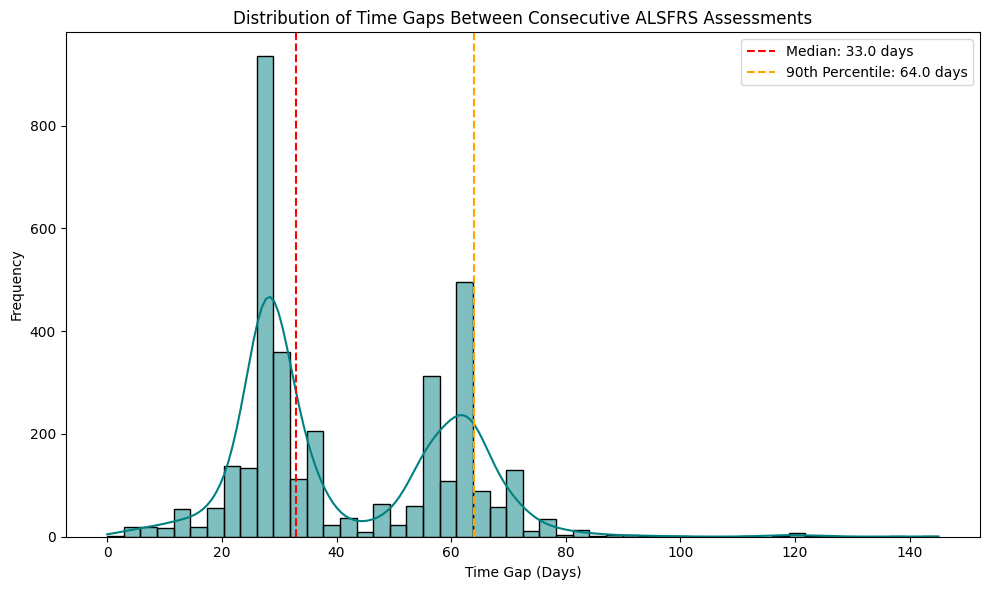

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('proact_preprocessed_S1.csv')

# Sort by subject and time to ensure sequential differences are correct
df = df.sort_values(by=['subject_id', 'ALSFRS_Delta'])

# Calculate the time gap (in days) between consecutive visits for each subject
df['Time_Gap'] = df.groupby('subject_id')['ALSFRS_Delta'].diff()

# Drop the NaN values which correspond to the baseline (first visit) of each subject
time_gaps = df['Time_Gap'].dropna()

# Generate descriptive statistics
stats = time_gaps.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Summary Statistics of Time Gaps (in days):")
print(stats)

# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.histplot(time_gaps, bins=50, kde=True, color='teal')
plt.title('Distribution of Time Gaps Between Consecutive ALSFRS Assessments')
plt.xlabel('Time Gap (Days)')
plt.ylabel('Frequency')
plt.axvline(x=stats['50%'], color='red', linestyle='--', label=f"Median: {stats['50%']:.1f} days")
plt.axvline(x=stats['90%'], color='orange', linestyle='--', label=f"90th Percentile: {stats['90%']:.1f} days")
plt.legend()
plt.tight_layout()
plt.savefig('time_gaps_distribution.png')
plt.show()

 EXPLORATORY DATA ANALYSIS: RAW BASELINE COVARIATES 

--- Treatment_Active ---
                  Count  Percentage (%)
Treatment_Active                       
1.0                7881           60.09
0.0                3553           27.09
NaN                1681           12.82

--- Bulbar_Onset ---
              Count  Percentage (%)
Bulbar_Onset                       
0.0           10274           78.34
NaN            1459           11.12
1.0            1382           10.54

--- Sex_Female ---
            Count  Percentage (%)
Sex_Female                       
0.0          7997           60.98
1.0          5118           39.02

--- Age_Base ---
count    10094.00
mean        56.65
std         11.58
min          0.00
25%         49.00
50%         58.00
75%         65.00
max         90.00
Name: Age_Base, dtype: float64

--- FVC_Base ---
count    3511.00
mean       76.78
std        26.72
min         0.00
25%        65.00
50%        80.00
75%        93.00
max       158.99
Name: FVC_Base, 

/u/zwu1/.conda/envs/emlou/lib/python3.12/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/tmp/ipykernel_1536068/2589515275.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=eda_df, x=col, ax=ax, palette='viridis', order=eda_df[col].value_counts().index)
/tmp/ipykernel_1536068/2589515275.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=eda_df, x=col, ax=ax, palette='viridis', order=eda_df[col].value_counts().index)
/tmp/ipykernel_1536068/2589515275.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia


=> Visualization successfully saved to 'raw_covariates_eda.png'


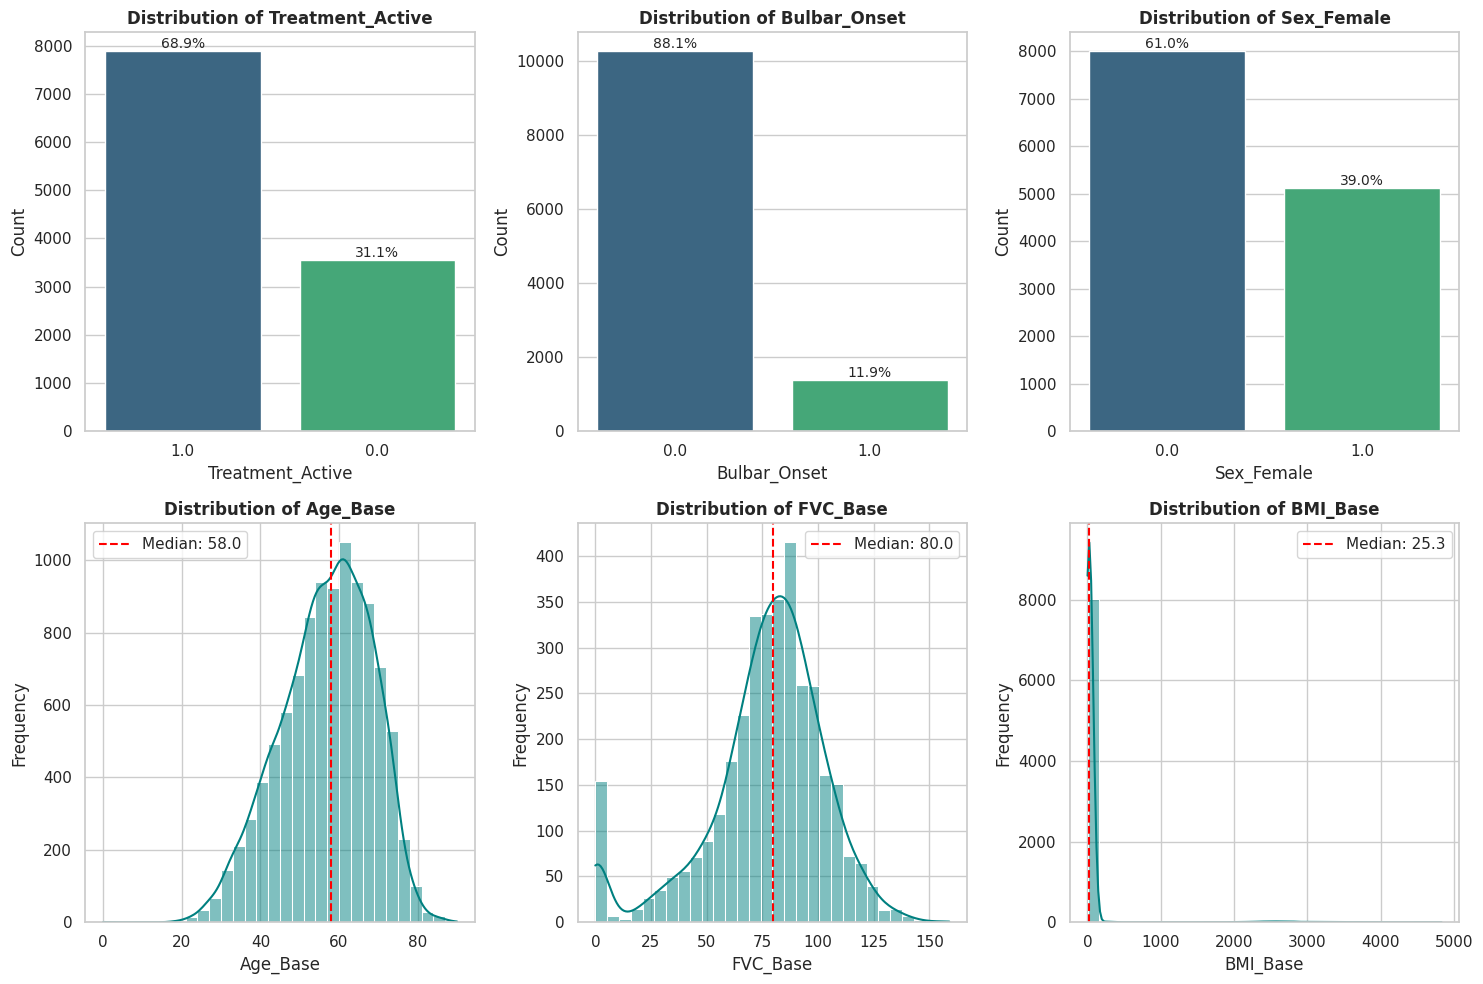

Preprocessed data for S1 successfully saved to 'proact_preprocessed_S1_new.csv' (N=4336 records)


,subject_id,ALSFRS_Delta,Q1_Speech,Q2_Salivation,Q3_Swallowing,Q4_Handwriting,Q5_Cutting,Q6_Dressing_and_Hygiene,Q7_Turning_in_Bed,Q8_Walking,Q9_Climbing_Stairs,R_1_Dyspnea,R_2_Orthopnea,R_3_Respiratory_Insufficiency,Age_Base,Sex_Female,Treatment_Active,Bulbar_Onset,FVC_Base,BMI_Base
0,16497,0.0,4.0,4.0,4.0,3.0,3.0,2.0,1.0,1.0,0.0,4.0,4.0,4.0,0.016919,1.0,1.0,0.0,0.126976,-0.356485
1,53215,8.0,3.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
2,53215,71.0,3.0,2.0,4.0,3.0,4.0,3.0,3.0,3.0,1.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
3,53215,140.0,3.0,3.0,4.0,3.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
4,53215,204.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4331,9998247,68.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,3.0,2.0,2.0,4.0,4.0,-0.154883,0.0,1.0,0.0,0.775334,2.615881
4332,9998247,95.0,3.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,2.0,2.0,3.0,4.0,-0.154883,0.0,1.0,0.0,0.775334,2.615881
4333,9998247,123.0,3.0,3.0,3.0,2.0,1.0,2.0,3.0,3.0,2.0,2.0,3.0,3.0,-0.154883,0.0,1.0,0.0,0.775334,2.615881
4334,9998247,151.0,3.0,3.0,3.0,2.0,2.0,3.0,3.0,2.0,2.0,2.0,4.0,4.0,-0.154883,0.0,1.0,0.0,0.775334,2.615881


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the 12 ALSFRS-R items as a constant
ITEM_COLS = [
    'Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing', 'Q4_Handwriting',
    'Q5_Cutting', 'Q6_Dressing_and_Hygiene', 'Q7_Turning_in_Bed',
    'Q8_Walking', 'Q9_Climbing_Stairs', 'R_1_Dyspnea',
    'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency'
]

def get_covariate_lists(scenario):
    """Returns the measurement and dynamic covariates based on the selected scenario."""
    if scenario == 'S1':
        meas_cols = ['Treatment_Active', 'Sex_Female', 'Age_Base']
        dyn_cols = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
    elif scenario == 'S2':
        meas_cols = ['Treatment_Active', 'Sex_Female', 'Age_Base']
        dyn_cols = ['Bulbar_Onset']
    elif scenario == 'S3':
        meas_cols = ['Treatment_Active', 'Sex_Female']
        dyn_cols = ['Age_Base', 'Bulbar_Onset']
    else:
        raise ValueError(f"Invalid scenario specified: {scenario}")
        
    return meas_cols, dyn_cols

def eda_raw_covariates(eda_df, active_covariates):
    """Generates printed and visual EDA for the extracted raw baseline covariates."""
    print("="*60)
    print(" EXPLORATORY DATA ANALYSIS: RAW BASELINE COVARIATES ")
    print("="*60)
    
    # Filter to only the active covariates for the chosen scenario
    eda_cols = [col for col in active_covariates if col in eda_df.columns]
    
    cat_cols = ['Treatment_Active', 'Sex_Female', 'Bulbar_Onset']
    cont_cols = ['Age_Base', 'FVC_Base', 'BMI_Base']

    # 1. Printed Stats
    for col in eda_cols:
        print(f"\n--- {col} ---")
        if col in cat_cols:
            # Calculate counts and ratios (including missing data)
            counts = eda_df[col].value_counts(dropna=False)
            ratios = eda_df[col].value_counts(normalize=True, dropna=False) * 100
            stats_df = pd.DataFrame({'Count': counts, 'Percentage (%)': ratios})
            print(stats_df.round(2))
        elif col in cont_cols:
            # Summary stats for continuous variables
            print(eda_df[col].describe().round(2))

    # 2. Visualizations
    num_plots = len(eda_cols)
    cols_per_row = 3
    num_rows = int(np.ceil(num_plots / cols_per_row))
    
    fig, axes = plt.subplots(nrows=num_rows, ncols=cols_per_row, figsize=(15, 5 * num_rows))
    axes = axes.flatten() if num_plots > 1 else [axes]
    sns.set_theme(style="whitegrid")
    
    for idx, col in enumerate(eda_cols):
        ax = axes[idx]
        if col in cat_cols:
            sns.countplot(data=eda_df, x=col, ax=ax, palette='viridis', order=eda_df[col].value_counts().index)
            ax.set_title(f'Distribution of {col}', fontweight='bold')
            ax.set_ylabel('Count')
            # Add percentage labels on top of bars
            total = len(eda_df[col].dropna())
            for p in ax.patches:
                height = p.get_height()
                if height > 0:
                    ax.annotate(f'{height/total*100:.1f}%', 
                                (p.get_x() + p.get_width() / 2., height), 
                                ha='center', va='bottom', fontsize=10)
        elif col in cont_cols:
            sns.histplot(data=eda_df, x=col, kde=True, ax=ax, color='teal', bins=30)
            ax.set_title(f'Distribution of {col}', fontweight='bold')
            ax.set_ylabel('Frequency')
            # Add median line
            median_val = eda_df[col].median()
            ax.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.1f}')
            ax.legend()
            
    # Hide any unused subplots
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout()
    plt.savefig('raw_covariates_eda.png', dpi=300)
    print("\n=> Visualization successfully saved to 'raw_covariates_eda.png'")
    plt.show()

def preprocess_proact_data(dfs, scenario="S1", output_filename="proact_preprocessed.csv"):
    """
    Preprocesses the PRO-ACT dataset dictionary, runs EDA on raw covariates,
    and filters complete cases dynamically based on the chosen scenario.
    """
    meas_cols, dyn_cols = get_covariate_lists(scenario)
    active_covariates = list(set(meas_cols + dyn_cols))
    
    # 1. RESPONSE VARIABLES (Y) & TIME
    df_alsfrs = dfs['alsfrs'].copy()
    df_alsfrs['Q5_Cutting'] = df_alsfrs['Q5b_Cutting_with_Gastrostomy'].fillna(df_alsfrs['Q5a_Cutting_without_Gastrostomy'])
    df_model = df_alsfrs[['subject_id', 'ALSFRS_Delta'] + ITEM_COLS].copy()
    df_model = df_model.dropna(subset=['ALSFRS_Delta'])
    
    # 2. MEASUREMENT COVARIATES 
    df_demo = dfs['demographics'].copy()
    df_demo['Sex_Female'] = (df_demo['Sex'] == 'Female').astype(float)
    df_demo_clean = df_demo.groupby('subject_id')[['Age', 'Sex_Female']].first().reset_index()
    df_demo_clean.rename(columns={'Age': 'Age_Base'}, inplace=True)
    
    df_tx = dfs['treatment'].copy()
    df_tx['Treatment_Active'] = df_tx['Study_Arm'].str.contains('Active', case=False, na=False).astype(float)
    df_tx_clean = df_tx.groupby('subject_id')[['Treatment_Active']].first().reset_index()
    
    # 3. DYNAMIC COVARIATES 
    df_hist = dfs['history'].copy()
    if 'Site_of_Onset___Bulbar' in df_hist.columns:
        df_hist['Bulbar_Onset'] = df_hist['Site_of_Onset___Bulbar'].fillna(0)
    else:
        df_hist['Bulbar_Onset'] = (df_hist['Site_of_Onset'] == 'Bulbar').astype(float)
    df_hist_clean = df_hist.groupby('subject_id')[['Bulbar_Onset']].first().reset_index()
    
    df_fvc = dfs['fvc'].copy()
    df_fvc['pct_of_Normal_Trial_1'] = pd.to_numeric(df_fvc['pct_of_Normal_Trial_1'], errors='coerce')
    fvc = df_fvc.dropna(subset=['pct_of_Normal_Trial_1', 'Forced_Vital_Capacity_Delta']).copy()
    fvc['abs_delta'] = fvc['Forced_Vital_Capacity_Delta'].abs()
    fvc_base = fvc.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    fvc_base = fvc_base.rename(columns={'pct_of_Normal_Trial_1': 'FVC_Base'})[['subject_id', 'FVC_Base']]
    
    df_vitals = dfs['vitals'].copy()
    df_vitals['Height_m'] = np.where(
        df_vitals['Height_Units'].str.lower().str.contains('in', na=False), 
        df_vitals['Height'] * 0.0254, df_vitals['Height'] / 100.0
    )
    heights = df_vitals.dropna(subset=['Height_m']).groupby('subject_id')['Height_m'].median().reset_index()
    
    df_vitals['Weight_kg'] = np.where(
        df_vitals['Weight_Units'].str.lower().str.contains('lb|pound', na=False), 
        df_vitals['Weight'] * 0.453592, df_vitals['Weight']
    )
    weights = df_vitals.dropna(subset=['Weight_kg', 'Vital_Signs_Delta']).copy()
    weights['abs_delta'] = weights['Vital_Signs_Delta'].abs()
    weights_base = weights.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    
    bmi_df = weights_base[['subject_id', 'Weight_kg']].merge(heights, on='subject_id', how='left')
    bmi_df['BMI_Base'] = bmi_df['Weight_kg'] / (bmi_df['Height_m'] ** 2)
    bmi_base = bmi_df[['subject_id', 'BMI_Base']]
    
    # ---------------------------------------------------------
    # NEW: RUN EXPLORATORY DATA ANALYSIS ON RAW COVARIATES
    # Merge baseline covariates specifically to assess the raw cohort
    eda_df = df_demo_clean.merge(df_tx_clean, on='subject_id', how='outer')\
                          .merge(df_hist_clean, on='subject_id', how='outer')\
                          .merge(fvc_base, on='subject_id', how='outer')\
                          .merge(bmi_base, on='subject_id', how='outer')
    
    eda_raw_covariates(eda_df, active_covariates)
    # ---------------------------------------------------------

    # 4. MERGE FOR MODELING
    df_model = df_model.merge(df_demo_clean, on='subject_id', how='left')
    df_model = df_model.merge(df_tx_clean, on='subject_id', how='left')
    df_model = df_model.merge(df_hist_clean, on='subject_id', how='left')
    df_model = df_model.merge(fvc_base, on='subject_id', how='left')
    df_model = df_model.merge(bmi_base, on='subject_id', how='left')
    
    df_model = df_model.sort_values(by=['subject_id', 'ALSFRS_Delta']).reset_index(drop=True)
    
    # 5. DYNAMIC COMPLETE CASE FILTER
    required_cols = ITEM_COLS + active_covariates
    df_complete = df_model.dropna(subset=required_cols).reset_index(drop=True)
    
    # Standardize continuous covariates for Stan HMC stability
    continuous_vars = ['Age_Base', 'FVC_Base', 'BMI_Base']
    for col in continuous_vars:
        if col in df_complete.columns and col in active_covariates:
            df_complete[col] = (df_complete[col] - df_complete[col].mean()) / df_complete[col].std()
            
    # Save the prepared data
    df_complete.to_csv(output_filename, index=False)
    print(f"Preprocessed data for {scenario} successfully saved to '{output_filename}' (N={len(df_complete)} records)")
    
    return df_complete

preprocess_proact_data(datasets, scenario="S1", output_filename="proact_preprocessed_S1_info.csv")


 EXPLORATORY DATA ANALYSIS: COVARIATES (RAW) 

--- Continuous Covariates Summary ---
          count        mean         std        min        50%          max
Age_Base  775.0   56.010452   11.519644  22.000000  57.000000    82.000000
FVC_Base  775.0   84.278916   18.803708   3.720000  84.000000   146.000000
BMI_Base  775.0  351.239051  885.998869   2.307219  27.995203  4828.238001

--- Categorical Covariates Proportions ---

Treatment_Active:
                  Count  Percentage (%)
Treatment_Active                       
1.0                 561           72.39
0.0                 214           27.61

Bulbar_Onset:
              Count  Percentage (%)
Bulbar_Onset                       
0.0             644            83.1
1.0             131            16.9

Sex_Female:
            Count  Percentage (%)
Sex_Female                       
0.0           495           63.87
1.0           280           36.13


/tmp/ipykernel_1536068/2207728823.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette='viridis')
/tmp/ipykernel_1536068/2207728823.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette='viridis')
/tmp/ipykernel_1536068/2207728823.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette='viridis')



[INFO] Covariate visualizations successfully saved to 'covariate_distributions_raw.png'.



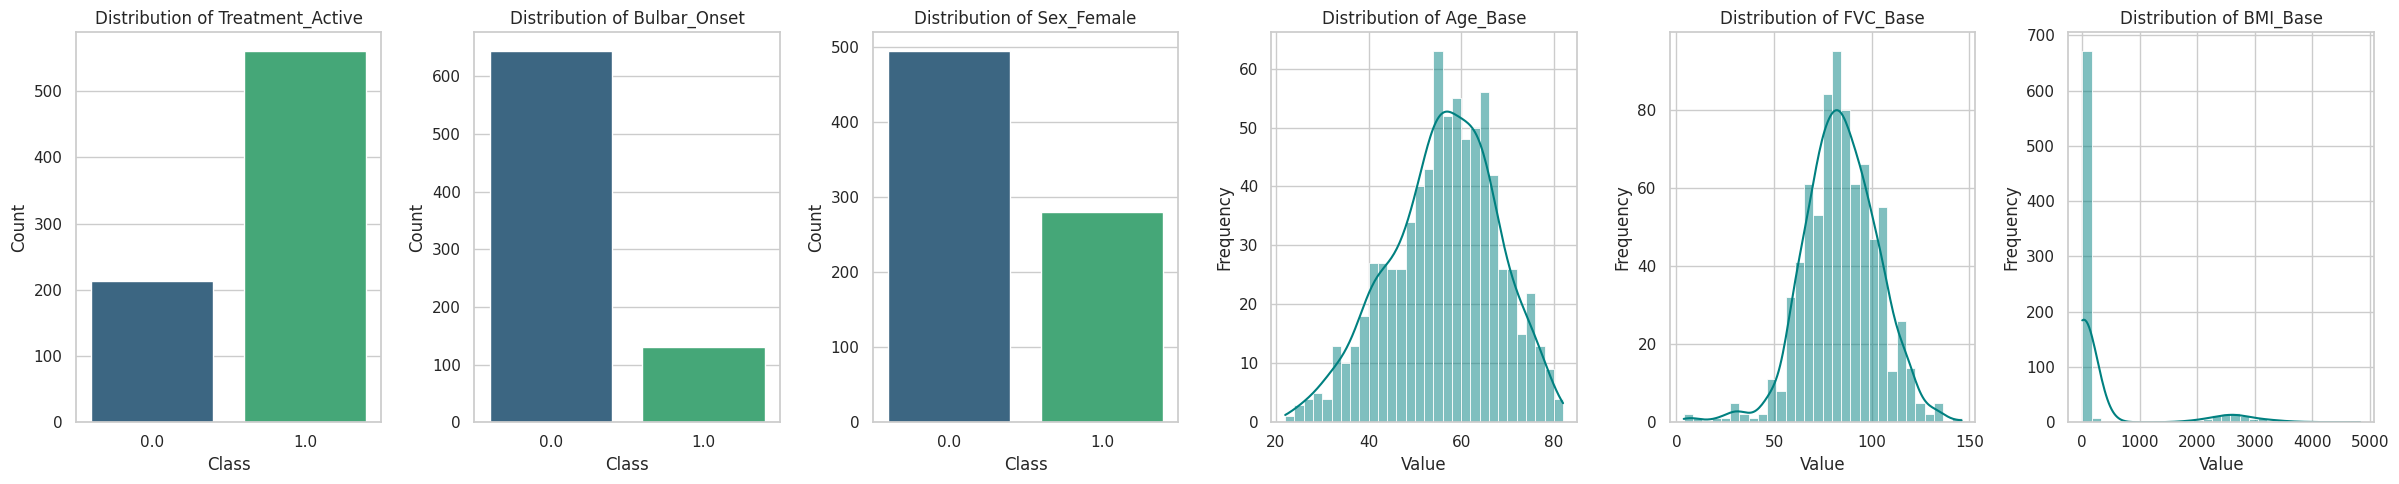

Preprocessed data for S1 successfully saved to 'proact_preprocessed_S1_new2.csv' (N=4336)


,subject_id,ALSFRS_Delta,Q1_Speech,Q2_Salivation,Q3_Swallowing,Q4_Handwriting,Q5_Cutting,Q6_Dressing_and_Hygiene,Q7_Turning_in_Bed,Q8_Walking,Q9_Climbing_Stairs,R_1_Dyspnea,R_2_Orthopnea,R_3_Respiratory_Insufficiency,Age_Base,Sex_Female,Treatment_Active,Bulbar_Onset,FVC_Base,BMI_Base
0,16497,0.0,4.0,4.0,4.0,3.0,3.0,2.0,1.0,1.0,0.0,4.0,4.0,4.0,0.016919,1.0,1.0,0.0,0.126976,-0.356485
1,53215,8.0,3.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
2,53215,71.0,3.0,2.0,4.0,3.0,4.0,3.0,3.0,3.0,1.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
3,53215,140.0,3.0,3.0,4.0,3.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
4,53215,204.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4331,9998247,68.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,3.0,2.0,2.0,4.0,4.0,-0.154883,0.0,1.0,0.0,0.775334,2.615881
4332,9998247,95.0,3.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,2.0,2.0,3.0,4.0,-0.154883,0.0,1.0,0.0,0.775334,2.615881
4333,9998247,123.0,3.0,3.0,3.0,2.0,1.0,2.0,3.0,3.0,2.0,2.0,3.0,3.0,-0.154883,0.0,1.0,0.0,0.775334,2.615881
4334,9998247,151.0,3.0,3.0,3.0,2.0,2.0,3.0,3.0,2.0,2.0,2.0,4.0,4.0,-0.154883,0.0,1.0,0.0,0.775334,2.615881


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the 12 ALSFRS-R items as a constant so it can be used during loading
ITEM_COLS = [
    'Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing', 'Q4_Handwriting',
    'Q5_Cutting', 'Q6_Dressing_and_Hygiene', 'Q7_Turning_in_Bed',
    'Q8_Walking', 'Q9_Climbing_Stairs', 'R_1_Dyspnea',
    'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency'
]

def get_covariate_lists(scenario):
    """
    Returns the measurement and dynamic covariates based on the selected scenario.
    """
    if scenario == 'S1':
        meas_cols = ['Treatment_Active', 'Sex_Female', 'Age_Base']
        dyn_cols = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
    elif scenario == 'S2':
        meas_cols = ['Treatment_Active', 'Sex_Female', 'Age_Base']
        dyn_cols = ['Bulbar_Onset']
    elif scenario == 'S3':
        meas_cols = ['Treatment_Active', 'Sex_Female']
        dyn_cols = ['Age_Base', 'Bulbar_Onset']
    else:
        raise ValueError(f"Invalid scenario specified: {scenario}")
        
    return meas_cols, dyn_cols

def explore_covariates(df, active_covariates):
    """
    Prints descriptive stats and generates visualizations for the covariates
    using raw values before standardization.
    """
    print("\n" + "="*50)
    print(" EXPLORATORY DATA ANALYSIS: COVARIATES (RAW) ")
    print("="*50)
    
    # Auto-detect binary/categorical vs. continuous covariates
    # Assuming any column with strictly {0, 1} or {0.0, 1.0} is categorical
    categorical = [c for c in active_covariates if set(df[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
    continuous = [c for c in active_covariates if c not in categorical]
    
    # 1. Printed Statistical Summary
    if continuous:
        print("\n--- Continuous Covariates Summary ---")
        stats_df = df[continuous].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
        print(stats_df.to_string())
        
    if categorical:
        print("\n--- Categorical Covariates Proportions ---")
        for col in categorical:
            counts = df[col].value_counts(dropna=False)
            ratios = df[col].value_counts(normalize=True, dropna=False) * 100
            summary = pd.DataFrame({'Count': counts, 'Percentage (%)': ratios})
            print(f"\n{col}:")
            print(summary.round(2).to_string())

    # 2. Visualizations
    n_cols = len(active_covariates)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5))
    
    # Handle the case where there is only one covariate (axes is not an array)
    if n_cols == 1: 
        axes = [axes] 
    
    for ax, col in zip(axes, active_covariates):
        if col in categorical:
            sns.countplot(data=df, x=col, ax=ax, palette='viridis')
            ax.set_title(f"Distribution of {col}")
            ax.set_ylabel("Count")
            ax.set_xlabel("Class")
        else:
            sns.histplot(data=df, x=col, ax=ax, kde=True, color='teal', bins=30)
            ax.set_title(f"Distribution of {col}")
            ax.set_ylabel("Frequency")
            ax.set_xlabel("Value")
            
    plt.tight_layout()
    plot_filename = 'covariate_distributions_raw.png'
    plt.savefig(plot_filename)
    print(f"\n[INFO] Covariate visualizations successfully saved to '{plot_filename}'.\n")
    plt.show()

def preprocess_proact_data(dfs, scenario="S1", output_filename="proact_preprocessed.csv"):
    """
    Preprocesses the PRO-ACT dataset dictionary.
    Filters complete cases dynamically based on the covariates required for the chosen scenario.
    """
    meas_cols, dyn_cols = get_covariate_lists(scenario)
    active_covariates = list(set(meas_cols + dyn_cols))
    
    # 1. RESPONSE VARIABLES (Y) & TIME
    df_alsfrs = dfs['alsfrs'].copy()
    df_alsfrs['Q5_Cutting'] = df_alsfrs['Q5b_Cutting_with_Gastrostomy'].fillna(df_alsfrs['Q5a_Cutting_without_Gastrostomy'])
    df_model = df_alsfrs[['subject_id', 'ALSFRS_Delta'] + ITEM_COLS].copy()
    df_model = df_model.dropna(subset=['ALSFRS_Delta'])
    
    # 2. MEASUREMENT COVARIATES 
    df_demo = dfs['demographics'].copy()
    df_demo['Sex_Female'] = (df_demo['Sex'] == 'Female').astype(float)
    df_demo_clean = df_demo.groupby('subject_id')[['Age', 'Sex_Female']].first().reset_index()
    df_demo_clean.rename(columns={'Age': 'Age_Base'}, inplace=True)
    
    df_tx = dfs['treatment'].copy()
    df_tx['Treatment_Active'] = df_tx['Study_Arm'].str.contains('Active', case=False, na=False).astype(float)
    df_tx_clean = df_tx.groupby('subject_id')[['Treatment_Active']].first().reset_index()
    
    # 3. DYNAMIC COVARIATES 
    df_hist = dfs['history'].copy()
    if 'Site_of_Onset___Bulbar' in df_hist.columns:
        df_hist['Bulbar_Onset'] = df_hist['Site_of_Onset___Bulbar'].fillna(0)
    else:
        df_hist['Bulbar_Onset'] = (df_hist['Site_of_Onset'] == 'Bulbar').astype(float)
    df_hist_clean = df_hist.groupby('subject_id')[['Bulbar_Onset']].first().reset_index()
    
    df_fvc = dfs['fvc'].copy()
    df_fvc['pct_of_Normal_Trial_1'] = pd.to_numeric(df_fvc['pct_of_Normal_Trial_1'], errors='coerce')
    fvc = df_fvc.dropna(subset=['pct_of_Normal_Trial_1', 'Forced_Vital_Capacity_Delta']).copy()
    fvc['abs_delta'] = fvc['Forced_Vital_Capacity_Delta'].abs()
    fvc_base = fvc.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    fvc_base = fvc_base.rename(columns={'pct_of_Normal_Trial_1': 'FVC_Base'})[['subject_id', 'FVC_Base']]
    
    df_vitals = dfs['vitals'].copy()
    df_vitals['Height_m'] = np.where(
        df_vitals['Height_Units'].str.lower().str.contains('in', na=False), 
        df_vitals['Height'] * 0.0254, df_vitals['Height'] / 100.0
    )
    heights = df_vitals.dropna(subset=['Height_m']).groupby('subject_id')['Height_m'].median().reset_index()
    
    df_vitals['Weight_kg'] = np.where(
        df_vitals['Weight_Units'].str.lower().str.contains('lb|pound', na=False), 
        df_vitals['Weight'] * 0.453592, df_vitals['Weight']
    )
    weights = df_vitals.dropna(subset=['Weight_kg', 'Vital_Signs_Delta']).copy()
    weights['abs_delta'] = weights['Vital_Signs_Delta'].abs()
    weights_base = weights.sort_values(['subject_id', 'abs_delta']).groupby('subject_id').first().reset_index()
    
    bmi_df = weights_base[['subject_id', 'Weight_kg']].merge(heights, on='subject_id', how='left')
    bmi_df['BMI_Base'] = bmi_df['Weight_kg'] / (bmi_df['Height_m'] ** 2)
    
    # --- NEW: BMI OUTLIER MITIGATION ---
    # Replace biologically impossible BMI values (e.g., < 10 or > 100) with NaN.
    # These rows will automatically be removed in the complete case filter below.
    bmi_df['BMI_Base'] = np.where(
        (bmi_df['BMI_Base'] < 10) | (bmi_df['BMI_Base'] > 100), 
        np.nan, 
        bmi_df['BMI_Base']
    )
    # -----------------------------------

    bmi_base = bmi_df[['subject_id', 'BMI_Base']]
    
    # 4. MERGE
    df_model = df_model.merge(df_demo_clean, on='subject_id', how='left')
    df_model = df_model.merge(df_tx_clean, on='subject_id', how='left')
    df_model = df_model.merge(df_hist_clean, on='subject_id', how='left')
    df_model = df_model.merge(fvc_base, on='subject_id', how='left')
    df_model = df_model.merge(bmi_base, on='subject_id', how='left')
    
    # Sort chronologically
    df_model = df_model.sort_values(by=['subject_id', 'ALSFRS_Delta']).reset_index(drop=True)
    
    # 5. DYNAMIC COMPLETE CASE FILTER
    required_cols = ITEM_COLS + active_covariates
    df_complete = df_model.dropna(subset=required_cols).reset_index(drop=True)
    
    # --- EXPLORATORY DATA ANALYSIS ---
    # We pass a subject-level deduplicated slice for the EDA so baseline stats 
    # aren't skewed by patients with longer follow-ups (more longitudinal rows).
    df_baseline_only = df_complete.drop_duplicates(subset=['subject_id'], keep='first')
    explore_covariates(df_baseline_only, active_covariates)
    
    # Standardize continuous covariates for Stan HMC stability
    continuous_vars = ['Age_Base', 'FVC_Base', 'BMI_Base']
    for col in continuous_vars:
        if col in df_complete.columns and col in active_covariates:
            df_complete[col] = (df_complete[col] - df_complete[col].mean()) / df_complete[col].std()
            
    # Save the prepared data to file
    df_complete.to_csv(output_filename, index=False)
    print(f"Preprocessed data for {scenario} successfully saved to '{output_filename}' (N={len(df_complete)})")
    
    return df_complete

# Assuming datasets dictionary is defined prior
preprocess_proact_data(datasets, scenario="S1", output_filename="proact_preprocessed_S1_new.csv")